[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/kulinskij-tech/Synergetics/blob/main/syn_py_ua/syn_ua_05_amplitude_equations_patterns.ipynb)


# 05. Рівняння амплітуди і відбір структур

_Магістерський курс «Вступ до синергетики» · українська версія_

> **Провідне питання:** Чому поблизу порога зовсім різні системи описуються однаковими рівняннями?

**Як працювати з ноутбуком.** Виконуйте комірки послідовно, згори донизу. Якщо не зазначено інше, усі параметри безрозмірні. Пояснюйте зміст кожної діагностики: сама лише ефектна траєкторія ще не доводить самоорганізації.


## Результати навчання

Після опрацювання модуля ви зможете:

- використовувати симетрію, щоб обмежити допустимі члени рівняння амплітуди;
- знаходити амплітуду насичення і нелінійний зсув частоти;
- моделювати відбір структури зі скінченним хвильовим числом і перевіряти числову збіжність.


## Необхідний вступ: моди Фур'є та дисперсійні співвідношення

Просторове поле можна розкласти за модами Фур'є: $u(x,t)=\sum_k\hat u_k(t)e^{ikx}$. Оскільки $\partial_x^2e^{ikx}=-k^2e^{ikx}$, лінійне диференціальне рівняння в частинних похідних зі сталими коефіцієнтами розвиває кожне хвильове число незалежно. Підстановка $u\propto e^{\lambda(k)t+ikx}$ дає **дисперсійне співвідношення** $\lambda(k)$; моди з $\operatorname{Re}\lambda(k)>0$ зростають.

Довжина хвилі дорівнює $2\pi/k$. У скінченній періодичній області дозволені лише дискретні хвильові числа, а числова сітка надійно відтворює тільки хвилі, істотно довші за її крок. Комплексна амплітуда $A=Re^{i\phi}$ зручно зберігає і силу структури $R$, і її фазу або положення $\phi$.


## Універсальність поблизу порога

Комплексна амплітуда $A$ коливальної або рухомої моди часто задовольняє

$$\dot A=(\mu+i\omega_0)A-(g_r+i g_i)|A|^2A.$$

Фазова симетрія $A\mapsto Ae^{i\phi}$ забороняє сталий і квадратичний члени. За $\mu>0$ і $g_r>0$ стійка амплітуда дорівнює $|A|=\sqrt{\mu/g_r}$, а $g_i$ задає нелінійний зсув частоти.

Мінімальним польовим рівнянням для стаціонарних структур зі скінченним хвильовим числом є модель Свіфта—Гоенберга,

$$\partial_tu=ru-(1+\partial_x^2)^2u-u^3,$$

для якої лінійна швидкість росту $\sigma(k)=r-(1-k^2)^2$. Першою втрачає стійкість смуга мод поблизу $k=1$.


## Канонічна дисипативна структура: конвекція Релея—Бенара

Горизонтальний шар рідини, який підігрівають знизу й охолоджують згори, безперервно підтримується потоком тепла і водночас розсіює енергію через в'язкість та теплопровідність. Його початковий стан — нерухома теплопровідність, $\mathbf u=0$, із майже лінійним профілем температури. Плавучість підсилює вертикальне зміщення: тепла порція рідини легша за оточення. В'язкість і температуропровідність, навпаки, гасять його. Співвідношення цих ефектів задають числа

$$Ra=\frac{g\alpha\,\Delta T\,d^3}{\nu\kappa},\qquad Pr=\frac{\nu}{\kappa},$$

де $d$ — товщина шару, $\alpha$ — коефіцієнт теплового розширення, $\nu$ — кінематична в'язкість, а $\kappa$ — температуропровідність. Для ідеального протяжного шару між жорсткими ізотермічними пластинами теплопровідний стан втрачає стійкість за $Ra_c\simeq1708$, і надкритично народжується пара конвективних валів із горизонтальним періодом близько $2.016d$. Це особливо наочна **дисипативна структура**: впорядковані поля швидкості й температури існують лише доти, доки прикладена різниця температур підтримує потік енергії.

Поблизу порога знакова амплітуда $A$ критичної моди конвективних валів підкоряється тій самій обмеженій симетрією нормальній формі, яка проходить крізь увесь курс:

$$\tau_A\dot A=\epsilon A-g_AA^3,\qquad \epsilon=\frac{Ra-Ra_c}{Ra_c}.$$

Нижче порога стійким є $A=0$, а вище нього $|A|\propto\sqrt{\epsilon}$. Знак розрізняє симетрично пов'язані напрями циркуляції. Швидкі температурні й гідродинамічні моди підпорядковуються $A$, а надлишкове перенесення тепла достатньо близько до порога задовольняє $Nu-1\propto A^2$. Наведена нижче візуалізація є слабконелінійною реконструкцією критичної моди, а не прямим числовим розв'язком повних рівнянь Обербека—Буссінеска. У модулі 09 ми повернемося до того самого досліду й побачимо, як тримодове усічення Лоренца пов'язує його з детермінованим хаосом.


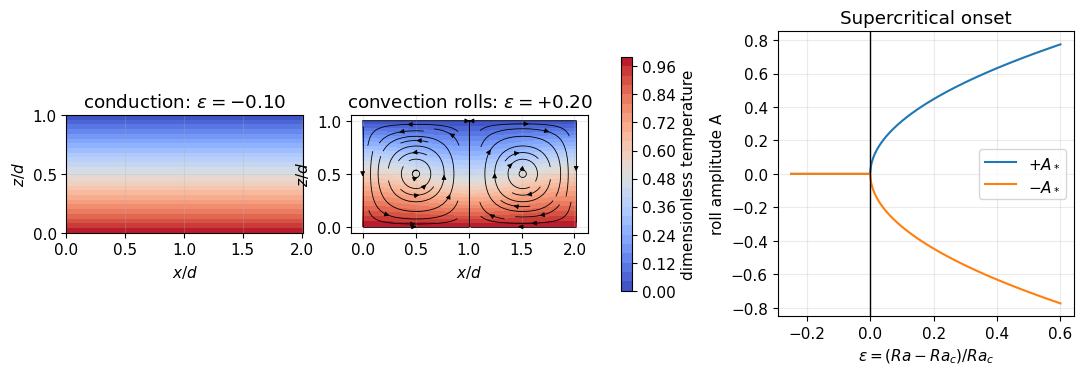

Near onset: A scales as sqrt(epsilon), while Nu - 1 scales as epsilon.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (7.2, 4.2),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 11,
})
rng = np.random.default_rng(20260904)

# Реконструкція критичної моди валів Релея—Бенара поблизу порога.
Ra_c, g_landau = 1708.0, 1.0
epsilon = np.linspace(-0.25, 0.60, 400)
A_branch = np.sqrt(np.maximum(epsilon, 0.0)/g_landau)

x_rb = np.linspace(0, 2.016, 150)
z_rb = np.linspace(0, 1, 90)
X_rb, Z_rb = np.meshgrid(x_rb, z_rb)
k_rb = 2*np.pi/2.016

fig, ax = plt.subplots(1, 3, figsize=(13, 3.7))
for axis, eps in zip(ax[:2], [-0.10, 0.20]):
    A = np.sqrt(max(eps, 0.0)/g_landau)
    psi = A*np.sin(k_rb*X_rb)*np.sin(np.pi*Z_rb)
    u_horizontal = A*np.pi*np.sin(k_rb*X_rb)*np.cos(np.pi*Z_rb)
    w_vertical = -A*k_rb*np.cos(k_rb*X_rb)*np.sin(np.pi*Z_rb)
    theta = 0.14*A*np.cos(k_rb*X_rb)*np.sin(np.pi*Z_rb)
    temperature = 1-Z_rb+theta
    filled = axis.contourf(X_rb, Z_rb, temperature, levels=24, cmap="coolwarm")
    if A > 0:
        axis.streamplot(x_rb, z_rb, u_horizontal, w_vertical,
                        color="k", density=0.75, linewidth=0.6, arrowsize=0.7)
    state = "conduction" if eps < 0 else "convection rolls"
    axis.set(xlabel=r"$x/d$", ylabel=r"$z/d$",
             title=fr"{state}: $\epsilon={eps:+.2f}$")
    axis.set_aspect("equal")

ax[2].plot(epsilon, A_branch, label=r"$+A_*$")
ax[2].plot(epsilon, -A_branch, label=r"$-A_*$")
ax[2].axvline(0, color="k", lw=1)
ax[2].set(xlabel=r"$\epsilon=(Ra-Ra_c)/Ra_c$", ylabel="roll amplitude A",
          title="Supercritical onset")
ax[2].legend()
fig.colorbar(filled, ax=ax[:2], shrink=0.82, label="dimensionless temperature")
plt.show()

Nu_minus_1 = A_branch**2
print("Near onset: A scales as sqrt(epsilon), while Nu - 1 scales as epsilon.")


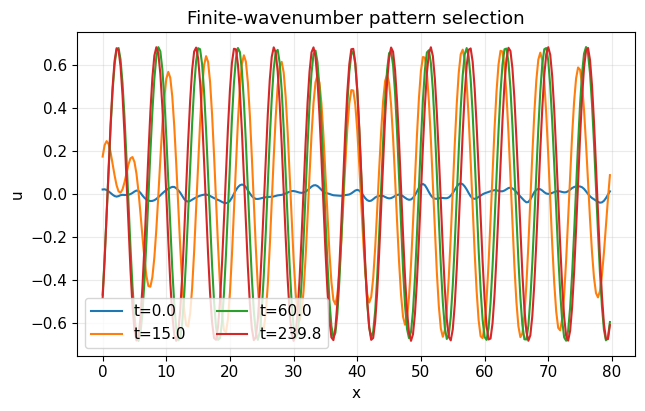

dominant wavenumber = 1.021; linear prediction near 1


In [2]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (7.2, 4.2),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 11,
})
rng = np.random.default_rng(20260904)

# Semi-implicit Fourier integration of the 1D Swift-Hohenberg equation.
N, L, dt, steps = 256, 80.0, 0.15, 1600
x = np.linspace(0, L, N, endpoint=False)
k = 2*np.pi*np.fft.fftfreq(N, d=L/N)
r = 0.35
linear = r - (1-k**2)**2
u = 0.05*rng.standard_normal(N)

snapshots = []
for n in range(steps):
    u_hat = np.fft.fft(u)
    nonlinear_hat = np.fft.fft(u**3)
    u_hat = (u_hat - dt*nonlinear_hat) / (1 - dt*linear)
    u = np.fft.ifft(u_hat).real
    if n in [0, 100, 400, steps-1]:
        snapshots.append((n*dt, u.copy()))

for t, field in snapshots:
    plt.plot(x, field, label=f"t={t:.1f}")
plt.xlabel("x")
plt.ylabel("u")
plt.title("Finite-wavenumber pattern selection")
plt.legend(ncol=2)
plt.show()

power = np.abs(np.fft.rfft(u))**2
k_pos = 2*np.pi*np.fft.rfftfreq(N, d=L/N)
k_peak = k_pos[1:][np.argmax(power[1:])]
print(f"dominant wavenumber = {k_peak:.3f}; linear prediction near 1")


## Числова обережність

Рівняння формування структур містять кілька масштабів і жорсткі лінійні оператори. Переконливий результат має повідомляти розмір області, кроки за простором і часом, граничні умови, тривалість перехідного процесу та перевірку збіжності. Поблизу порога скінченна область квантує дозволені хвильові числа, тому спостережене $k$ не зобов'язане точно збігатися з оптимумом для нескінченної системи.


## Оцінюване завдання

Повторіть моделювання Свіфта—Гоенберга для трьох значень $r$ поблизу порога і двох довжин області. Виміряйте насичену середньоквадратичну амплітуду та домінантне хвильове число. Перевірте передбачений показник $1/2$ для амплітуди й поясніть відхилення, спричинені скінченним розміром області.

Подання має містити чітке твердження, його математичне або фізичне обґрунтування, числові свідчення та принаймні одне обмеження висновку.


## Література та атрибуція

**Основне читання з локальної бібліотеки:** Haken, *Synergetics: Introduction and Advanced Topics*; Cross and Hohenberg, відбір структур і рівняння амплітуди.

**Перевірене вебджерело:**
- [Огляд Кросса і Гоенберга](https://doi.org/10.1103/RevModPhys.65.851)

Локальні книги є наданими матеріалами курсу. Вебпосилання мають додатковий характер; їх перевірено 04.09.2026.
